In [1]:
import numpy as np
import matplotlib.pyplot as plt

from models.timefm import TimesFMModel
from models.lstm import LSTMModel, QLSTMModel
from models.gan import QGanModel, MultiSequenceGAN
from sklearn.preprocessing import StandardScaler

/home/ton618wsl/qwhether_forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


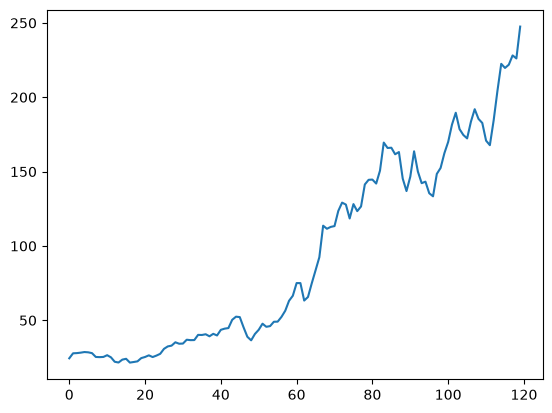

In [2]:
data = np.load('data/aapl_stock_monthly.npy')
plt.plot(data)

In [ ]:
## Times FM
model = TimesFMModel(data = data, horizon= 6, historical_lookup= 6)
contexts, predictions, actuals = model.backtest()
results = model.metrics(
    predictions,
    actuals
)
results

In [ ]:
## LSTM 

lstm = LSTMModel(
    data=data,
    horizon=6,
    historical_lookup=6,
    hidden_size=64,
    num_layers=2,
    dropout=0.1,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3,
    train_ratio=0.8
)

history = lstm.train()
contexts, predictions, actuals = lstm.backtest()
results = lstm.metrics(
    predictions,
    actuals
)
results

In [ ]:
qlstm = QLSTMModel(
    data=data,
    horizon=6,
    historical_lookup=6,

    hidden_size=16,
    n_qubits=4,
    quantum_layers=4,

    epochs=100,
    batch_size=8,
    learning_rate=1e-3,

    train_ratio=0.8
)

history = qlstm.train()
contexts, predictions, actuals = qlstm.backtest()   
results = qlstm.metrics(
    predictions,
    actuals
)
results

In [ ]:
## GAN - Single Sequence QC
qgan = QGanModel(
    data=data,
    type="QC",
    horizon=6,
    historical_lookup=6,
    latent_size=4,
    hidden_size=32,
    epochs=50,
    batch_size=32,
    learning_rate=1e-3
)
history = qgan.train()
contexts, predictions, actuals = qgan.backtest()   
results = qgan.metrics(predictions, actuals)
results

In [ ]:
## GAN - Single Sequence CC
qgan = QGanModel(
    data=data,
    type="CC",
    horizon=6,
    historical_lookup=6,
    latent_size=4,
    hidden_size=32,
    epochs=50,
    batch_size=32,
    learning_rate=1e-3
)
history = qgan.train()
contexts, predictions, actuals = qgan.backtest()   
results = qgan.metrics(predictions, actuals)
results

In [6]:
## GAN - Multi Sequence QC
msgan_qc = MultiSequenceGAN(
    data=data,
    type="QC",
    historical_lookup=24,
    horizon=6,
    latent_size=8,
    n_qubits=6,
    quantum_layers=10,
    hidden_size=32,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-4,
    diversity_loss_weight= 1.0,
    variety_loss_weight= 0.5,
    train_ratio=0.8,   # be explicit if you plan to compare CC/QC/CQ/QQ side by side
    seed=42,            # pin explicitly so this run is reproducible/comparable across architectures
)
history = msgan_qc.train()
d = msgan_qc.backtest(return_all_sequences=True)
contexts = d['contexts'] 
predictions = d['predictions']
actuals = d['actuals']    
all_seq = d['all_sequences']
prob_result = msgan_qc.probabilistic_metrics(all_seq, actuals)
results = msgan_qc.metrics(predictions, actuals)
results


Training Model C MultiSequenceGAN type=QC
Generator: Quantum
Discriminator: Classical
Trend: causal local linear (trend-aware residual GAN)
Residual mean: -0.014101
Residual std : 9.698998
Slope mean   : 1.707563
Slope std    : 1.422450
[QC] Epoch 1/1000 G=2.3848 D=0.6979 Variety=3.6004 Diversity=-0.0743
[QC] Epoch 10/1000 G=2.1986 D=0.6945 Variety=3.2224 Diversity=-0.0789
[QC] Epoch 20/1000 G=2.3812 D=0.6896 Variety=3.5992 Diversity=-0.0914
[QC] Epoch 30/1000 G=2.3811 D=0.6824 Variety=3.6088 Diversity=-0.1032
[QC] Epoch 40/1000 G=2.4190 D=0.6726 Variety=3.6817 Diversity=-0.1114
[QC] Epoch 50/1000 G=2.2227 D=0.6626 Variety=3.3177 Diversity=-0.1356
[QC] Epoch 60/1000 G=2.3320 D=0.6444 Variety=3.5313 Diversity=-0.1514
[QC] Epoch 70/1000 G=2.2443 D=0.6288 Variety=3.3662 Diversity=-0.1738
[QC] Epoch 80/1000 G=2.3313 D=0.5983 Variety=3.5025 Diversity=-0.1986
[QC] Epoch 90/1000 G=2.2276 D=0.5829 Variety=3.2955 Diversity=-0.2368
[QC] Epoch 100/1000 G=2.5107 D=0.5469 Variety=3.8074 Diversity=

{'overall': {'MAE': 24.759952545166016,
  'RMSE': 28.950902938842773,
  'MAPE': 13.306741714477539,
  'MAPE_excluded_fraction': 0.0,
  'R2': -0.8489810228347778},
 'per_horizon': {'Day +1': {'MAE': 16.73171615600586,
   'RMSE': 19.360980987548828,
   'MAPE': 9.434330940246582,
   'MAPE_excluded_fraction': 0.0,
   'R2': 0.003995180130004883},
  'Day +2': {'MAE': 17.20247459411621,
   'RMSE': 20.2652587890625,
   'MAPE': 9.28848648071289,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.1582552194595337},
  'Day +3': {'MAE': 22.975351333618164,
   'RMSE': 26.36109733581543,
   'MAPE': 12.532429695129395,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.8771376609802246},
  'Day +4': {'MAE': 25.04878044128418,
   'RMSE': 27.910619735717773,
   'MAPE': 13.46940803527832,
   'MAPE_excluded_fraction': 0.0,
   'R2': -0.967621922492981},
  'Day +5': {'MAE': 30.035852432250977,
   'RMSE': 33.804527282714844,
   'MAPE': 15.967755317687988,
   'MAPE_excluded_fraction': 0.0,
   'R2': -1.7247986793518066

In [7]:
prob_result

{'overall_CRPS': 14.22476367353527,
 'per_horizon_CRPS': {'Day +1': 14.59151569096729,
  'Day +2': 14.165645260524395,
  'Day +3': 12.473287590874566,
  'Day +4': 12.990051573733586,
  'Day +5': 15.22730708721025,
  'Day +6': 15.90077483790153}}

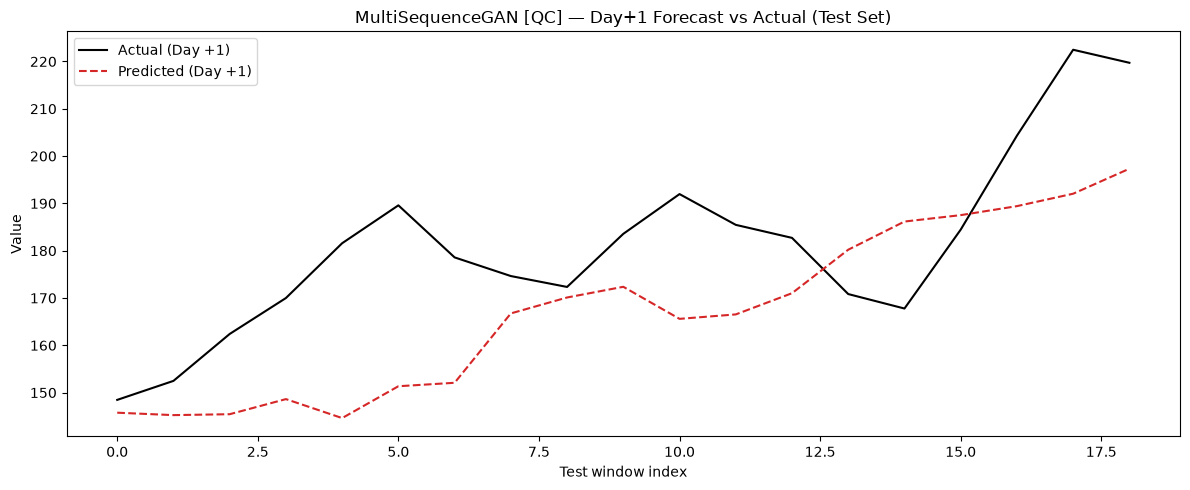

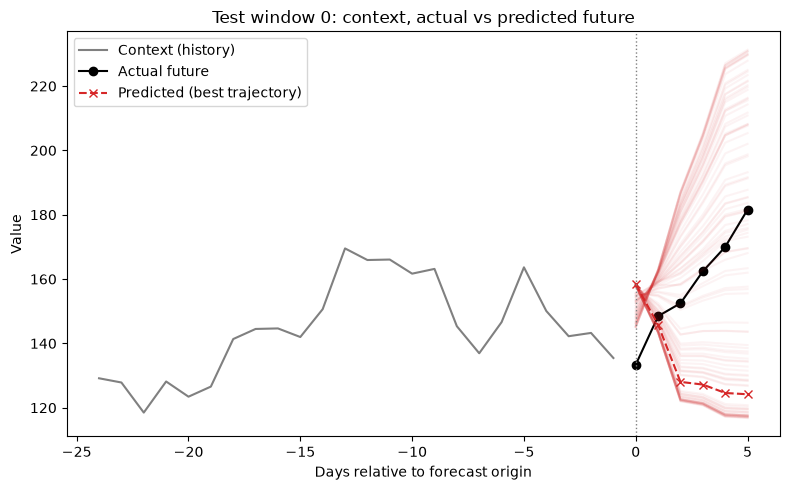

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Day+1-ahead forecast vs actual, across the whole chronological test set
day1_actual = actuals[:, 1]
day1_pred = predictions[:, 1]

plt.figure(figsize=(12, 5))
plt.plot(day1_actual, label="Actual (Day +1)", color="black")
plt.plot(day1_pred, label="Predicted (Day +1)", color="tab:red", linestyle="--")
plt.title(f"MultiSequenceGAN [{msgan_qc.type}] — Day+1 Forecast vs Actual (Test Set)")
plt.xlabel("Test window index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Full 6-day window for one test example: context, actual future, predicted
#    future, and the full generated ensemble spread
idx = 0  # change to inspect a different test window
ensemble = all_seq[idx]  # shape: (horizon, n_sequences)

x_context = np.arange(-msgan_qc.historical_lookup, 0)
x_future = np.arange(0, msgan_qc.horizon)

plt.figure(figsize=(8, 5))
plt.plot(x_context, contexts[idx], label="Context (history)", color="gray")
plt.plot(x_future, actuals[idx], label="Actual future", color="black", marker="o")
plt.plot(x_future, predictions[idx], label="Predicted (best trajectory)", color="tab:red", linestyle="--", marker="x")
for s in range(ensemble.shape[1]):
    plt.plot(x_future, ensemble[:, s], color="tab:red", alpha=0.05)  # faint ensemble spread
plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.title(f"Test window {idx}: context, actual vs predicted future")
plt.xlabel("Days relative to forecast origin")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()